# Data Visualisation 1 - Assignment 4

### Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataset

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Data cleaning

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.drop(columns = 'Cabin', inplace = True)

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [12]:
df = df.dropna(subset = ['Embarked'])

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

Missing values:
- Cabin column was dropped as it had too many missing values.
- Age value was imputed with means.
- Two rows containing null values for embarked were dropped.
No duplicate values found.

### Data Visualisation

##### Countplot:

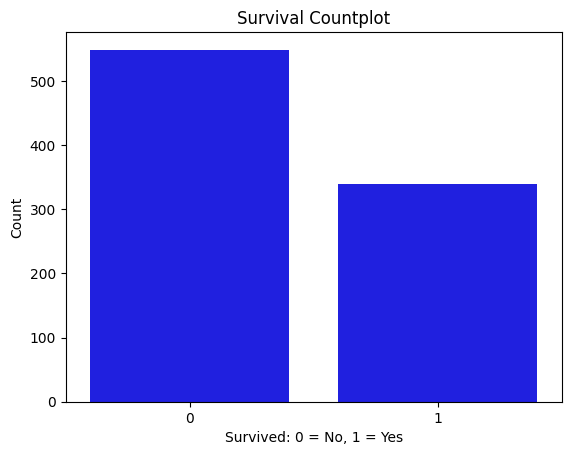

In [17]:
# countplot
sns.countplot(x = 'Survived', data = df, color = 'blue')
plt.xlabel('Survived: 0 = No, 1 = Yes')
plt.ylabel('Count')
plt.title('Survival Countplot')
plt.show()

Inference: Lesser number of people survived.

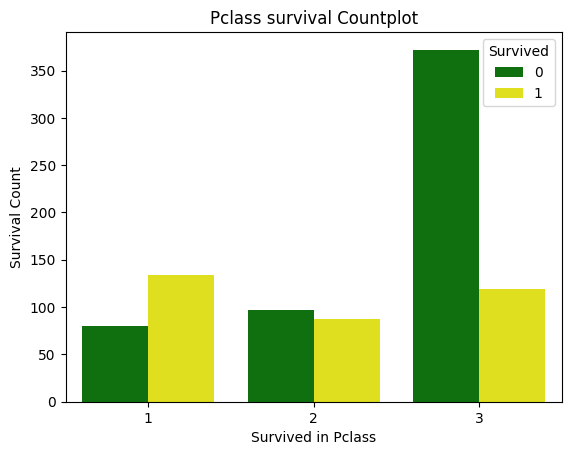

In [20]:
# countplot for passenger survival class
sns.countplot(x = 'Pclass', hue = 'Survived', data = df, palette = ['green','yellow'])
plt.xlabel('Survived in Pclass')
plt.ylabel('Survival Count')
plt.title('Pclass survival Countplot')
plt.show()

Inference: Most people from first class survived.

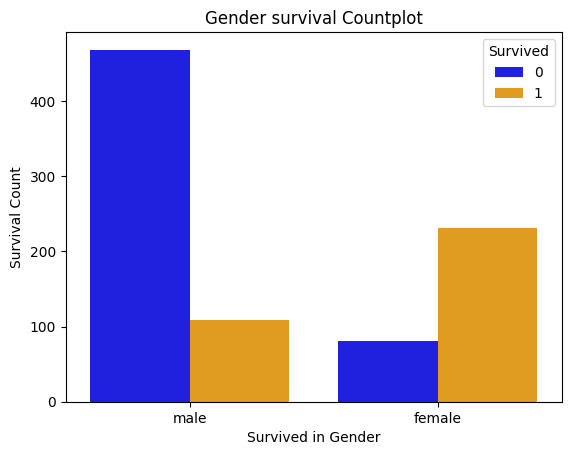

In [21]:
# countplot for gender survival 
sns.countplot(x = 'Sex', hue = 'Survived', data = df, palette = ['blue','orange'])
plt.xlabel('Survived in Gender')
plt.ylabel('Survival Count')
plt.title('Gender survival Countplot')
plt.show()

Inference: More women survived than men - shown that women were given a higher preference for safety. Lesser number of women embarked on the titanic.

##### Barplot:

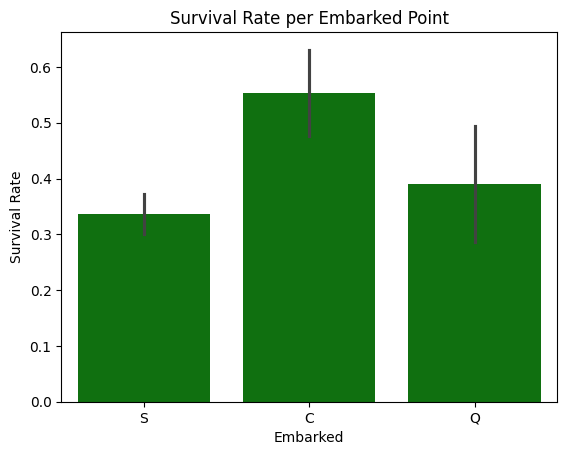

In [27]:
sns.barplot(data=df, x='Embarked', y='Survived', color='green')
plt.xlabel('Embarked')
plt.ylabel('Survival Rate')
plt.title('Survival Rate per Embarked Point')
plt.show()

Inference: Survival rate was the highest when embarkment point was from C.

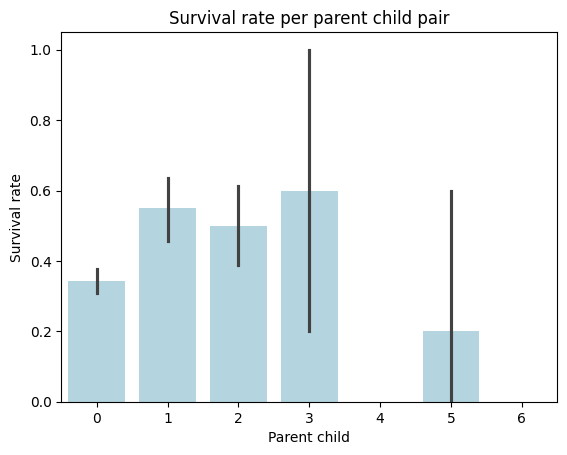

In [28]:
sns.barplot(data = df, x = 'Parch', y = 'Survived', color = 'lightblue')
plt.xlabel('Parent child')
plt.ylabel('Survival rate')
plt.title('Survival rate per parent child pair')
plt.show()

Inference: Passengers with 3 children had the highest survival rate amongst all.

##### Scatter plot:

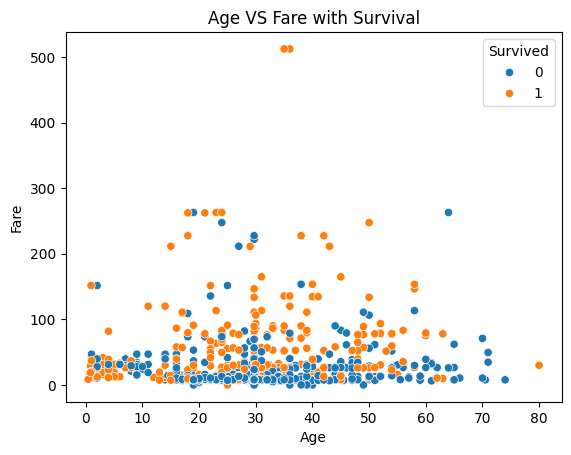

In [29]:
sns.scatterplot(x = 'Age', y = 'Fare', hue = 'Survived', data = df)
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age VS Fare with Survival')
plt.show()

Inference: Higher fare passengers and younger children were more likely to survive.

##### KDE Plot:
Kernel Density Estimation -> plots a smooth curve of distribution of probability density

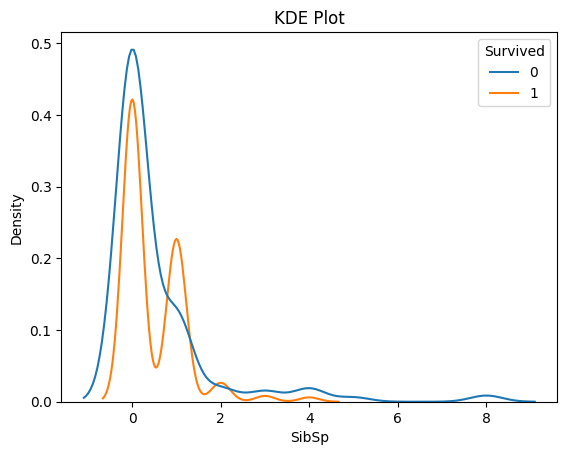

In [30]:
sns.kdeplot(x = 'SibSp', hue = 'Survived', data = df)
plt.xlabel('SibSp')
plt.title('KDE Plot')
plt.show()

Inference: Most passengers travelled alone and survival was higher among those with no siblings or spouses.

##### Line plot

In [31]:
bins = [0, 12, 18, 35, 60, 80]
labels = ['children', 'teens', 'young adults', 'adults', 'senior citizens']
df['AgeGroup'] = pd.cut(df['Age'], bins = bins, labels = labels)

In [32]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,young adults
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adults
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,young adults
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,young adults
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,young adults


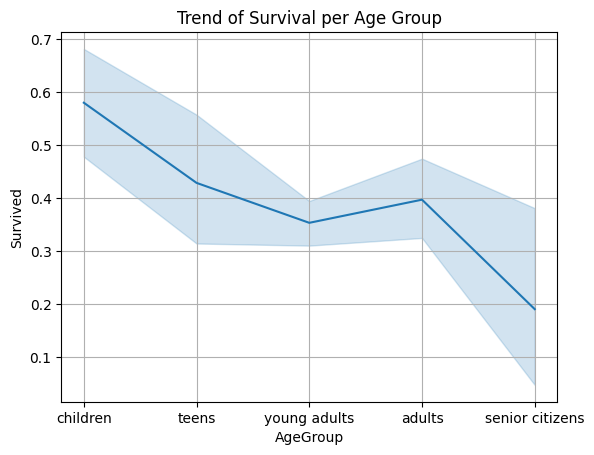

In [36]:
sns.lineplot(x = 'AgeGroup', y = 'Survived', data = df)
plt.xlabel('AgeGroup')
plt.title('Trend of Survival per Age Group')
plt.grid(True)
plt.show()

Inference: Children had a much higher survival rate than their older counterparts.

##### Histplot:

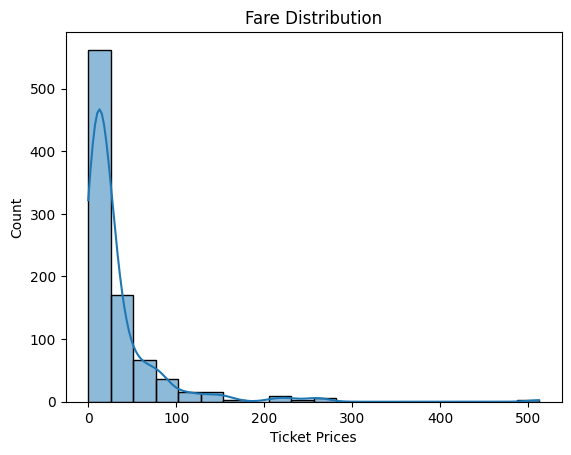

In [39]:
sns.histplot(x = 'Fare', data = df, bins = 20, kde = True)
plt.xlabel('Ticket Prices')
plt.title('Fare Distribution')
plt.show()

Inference: Most people onboard had paid the lower end of ticket prices. Distribution is highly right skewed.